<a href="https://colab.research.google.com/github/MarioRojasV/CNN_Models_Comparison_Bird_Classification/blob/main/src/cnn_basic_model/CNN_Basic_Birsd_COMPDES_2026_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report

print("GPU disponible:", tf.config.list_physical_devices('GPU'))

from google.colab import drive
drive.mount('/content/drive')

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mounted at /content/drive


In [2]:
BASE_PATH    = "/content/drive/MyDrive/Universidad/COMPDES2026_Aves_CR"
DATASET_PATH = BASE_PATH + "/Dataset"

TEST_REGULAR_PATH = DATASET_PATH + "/Testing_set/Regular_photos"
TEST_FLYING_PATH  = DATASET_PATH + "/Testing_set/Flying_photos"

MODEL_PATH   = BASE_PATH + "/Resultados/cnn_baseline_avesCR.keras"
RESULTS_PATH = BASE_PATH + "/Resultados"
os.makedirs(RESULTS_PATH, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

DISPLAY_LABELS = [
    "Quiscalus mexicanus\n(hembra)",
    "Turdus grayi"
]

In [3]:
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,656 (127.82 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,438 (85.21 MB)

In [4]:
def graficar_matriz_confusion(y_true, y_pred, labels, titulo, ruta_guardado, en_porcentaje=False):
    cm = confusion_matrix(y_true, y_pred)
    if en_porcentaje:
        datos = (cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]) * 100
        cmap, vmin, vmax = "Oranges", 0, 100
    else:
        datos = cm
        cmap, vmin, vmax = "Blues", None, None
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(datos, cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im)
    cbar.set_label("Porcentaje (%)" if en_porcentaje else "Cantidad de imágenes")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Clase predicha", fontsize=12, fontweight="bold")
    ax.set_ylabel("Clase real", fontsize=12, fontweight="bold")
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            texto = f"{cm[i, j]}\n({datos[i, j]:.1f}%)" if en_porcentaje else str(cm[i, j])
            ax.text(j, i, texto, ha="center", va="center",
                    fontsize=12 if en_porcentaje else 14,
                    fontweight="bold", color="black")
    plt.tight_layout()
    plt.savefig(ruta_guardado, dpi=300, bbox_inches="tight")
    plt.show()
    return cm

def analizar_confianza_por_categoria(y_true, y_pred, y_probs, titulo):
    confianza = y_probs[np.arange(len(y_pred)), y_pred]
    prob_clase_real = y_probs[np.arange(len(y_true)), y_true]
    perdida_por_imagen = -np.log(np.clip(prob_clase_real, 1e-7, 1.0))
    nombres_cortos = ["Q. mexicanus", "T. grayi"]
    print("=" * 65)
    print(f"ANÁLISIS DE CONFIANZA POR CATEGORÍA — {titulo}")
    print("=" * 65)
    for real in range(2):
        for predicha in range(2):
            mascara = (y_true == real) & (y_pred == predicha)
            n = int(mascara.sum())
            if n == 0:
                continue
            tipo = "✓ ACIERTO" if real == predicha else "✗ ERROR"
            conf    = confianza[mascara]
            perdida = perdida_por_imagen[mascara]
            print(f"\n{tipo} | Real: {nombres_cortos[real]}"
                  f"  →  Predicha: {nombres_cortos[predicha]}")
            print(f"  Cantidad de imágenes : {n}")
            print(f"  Confianza promedio   : {conf.mean()*100:.2f}%")
            print(f"  Confianza mínima     : {conf.min()*100:.2f}%")
            print(f"  Confianza máxima     : {conf.max()*100:.2f}%")
            print(f"  Pérdida promedio     : {perdida.mean():.4f}")
    print(f"\n  Pérdida global promedio: {perdida_por_imagen.mean():.4f}")
    print("=" * 65)

In [5]:
test_regular_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_REGULAR_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True
)

class_names = test_regular_ds.class_names
print("Clases (orden usado por el modelo):", class_names)

Found 80 files belonging to 2 classes.
Clases (orden usado por el modelo): ['Quiscalus_mexicanus_testing_photos', 'Turdus_grayi_testing_photos']


In [6]:
test_loss, test_accuracy = model.evaluate(test_regular_ds)
print("Test accuracy (CNN Básica, Regular Photos):", round(float(test_accuracy), 4))
print("Test loss    (CNN Básica, Regular Photos):", round(float(test_loss), 4))

y_true_regular  = []
y_pred_regular  = []
y_probs_regular = []

for images, labels in test_regular_ds:
    probs = model.predict(images, verbose=0)
    y_true_regular.extend(labels.numpy())
    y_pred_regular.extend(np.argmax(probs, axis=1))
    y_probs_regular.extend(probs)

y_true_regular  = np.array(y_true_regular)
y_pred_regular  = np.array(y_pred_regular)
y_probs_regular = np.array(y_probs_regular)

3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.8125 - loss: 0.4605
Test accuracy (CNN Básica, Regular Photos): 0.8125
Test loss    (CNN Básica, Regular Photos): 0.4605


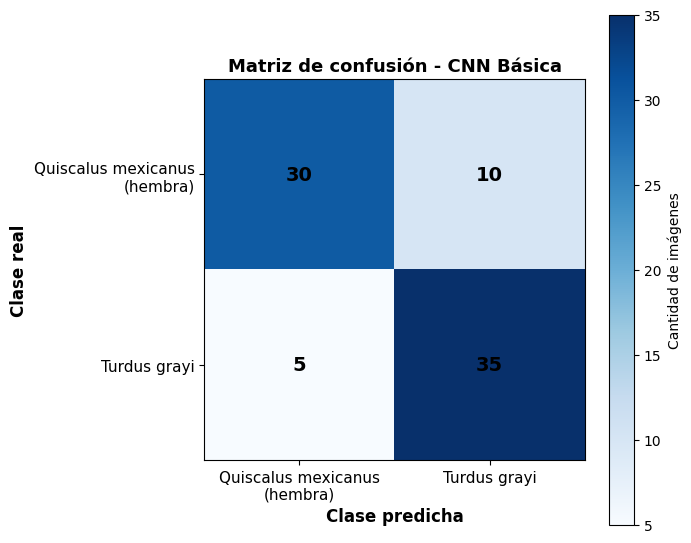

                                    precision    recall  f1-score   support

Quiscalus_mexicanus_testing_photos     0.8571    0.7500    0.8000        40
       Turdus_grayi_testing_photos     0.7778    0.8750    0.8235        40

                          accuracy                         0.8125        80
                         macro avg     0.8175    0.8125    0.8118        80
                      weighted avg     0.8175    0.8125    0.8118        80



In [7]:
cm_regular = graficar_matriz_confusion(
    y_true_regular, y_pred_regular, DISPLAY_LABELS,
    "Matriz de confusión - CNN Básica",
    RESULTS_PATH + "/Matriz_Confusion_CNN_Baseline_Regular.png"
)

print(classification_report(y_true_regular, y_pred_regular, target_names=class_names, digits=4))

In [8]:
test_flying_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_FLYING_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True
)

Found 20 files belonging to 2 classes.


In [9]:
flying_loss, flying_accuracy = model.evaluate(test_flying_ds)
print("Test accuracy (CNN Básica, Flying Photos):", round(float(flying_accuracy), 4))
print("Test loss    (CNN Básica, Flying Photos):", round(float(flying_loss), 4))

y_true_flying  = []
y_pred_flying  = []
y_probs_flying = []

for images, labels in test_flying_ds:
    probs = model.predict(images, verbose=0)
    y_true_flying.extend(labels.numpy())
    y_pred_flying.extend(np.argmax(probs, axis=1))
    y_probs_flying.extend(probs)

y_true_flying  = np.array(y_true_flying)
y_pred_flying  = np.array(y_pred_flying)
y_probs_flying = np.array(y_probs_flying)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6000 - loss: 0.9119
Test accuracy (CNN Básica, Flying Photos): 0.6
Test loss    (CNN Básica, Flying Photos): 0.9119


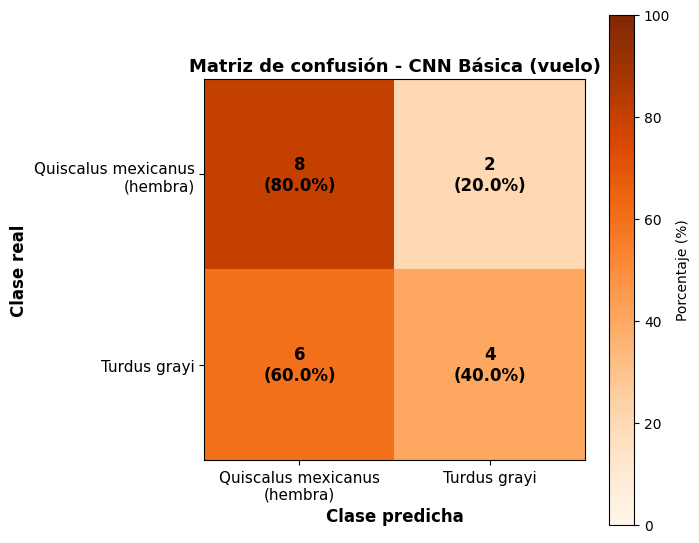

                                    precision    recall  f1-score   support

Quiscalus_mexicanus_testing_photos     0.5714    0.8000    0.6667        10
       Turdus_grayi_testing_photos     0.6667    0.4000    0.5000        10

                          accuracy                         0.6000        20
                         macro avg     0.6190    0.6000    0.5833        20
                      weighted avg     0.6190    0.6000    0.5833        20



In [10]:
cm_flying = graficar_matriz_confusion(
    y_true_flying, y_pred_flying, DISPLAY_LABELS,
    "Matriz de confusión - CNN Básica (vuelo)",
    RESULTS_PATH + "/Matriz_Confusion_CNN_Baseline_Flying.png",
    en_porcentaje=True
)

print(classification_report(y_true_flying, y_pred_flying, target_names=class_names, digits=4))

In [11]:
analizar_confianza_por_categoria(
    y_true_regular, y_pred_regular, y_probs_regular,
    "CNN Básica — Fotos regulares"
)

ANÁLISIS DE CONFIANZA POR CATEGORÍA — CNN Básica — Fotos regulares

✓ ACIERTO | Real: Q. mexicanus  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 30
  Confianza promedio   : 90.64%
  Confianza mínima     : 54.22%
  Confianza máxima     : 99.98%
  Pérdida promedio     : 0.1151

✗ ERROR | Real: Q. mexicanus  →  Predicha: T. grayi
  Cantidad de imágenes : 10
  Confianza promedio   : 75.90%
  Confianza mínima     : 59.10%
  Confianza máxima     : 99.40%
  Pérdida promedio     : 1.8386

✗ ERROR | Real: T. grayi  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 5
  Confianza promedio   : 78.90%
  Confianza mínima     : 54.59%
  Confianza máxima     : 90.22%
  Pérdida promedio     : 1.7017

✓ ACIERTO | Real: T. grayi  →  Predicha: T. grayi
  Cantidad de imágenes : 35
  Confianza promedio   : 84.43%
  Confianza mínima     : 55.07%
  Confianza máxima     : 99.64%
  Pérdida promedio     : 0.1855

  Pérdida global promedio: 0.4605


In [12]:
analizar_confianza_por_categoria(
    y_true_flying, y_pred_flying, y_probs_flying,
    "CNN Básica — Fotografías en vuelo"
)

ANÁLISIS DE CONFIANZA POR CATEGORÍA — CNN Básica — Fotografías en vuelo

✓ ACIERTO | Real: Q. mexicanus  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 8
  Confianza promedio   : 96.43%
  Confianza mínima     : 82.60%
  Confianza máxima     : 99.98%
  Pérdida promedio     : 0.0380

✗ ERROR | Real: Q. mexicanus  →  Predicha: T. grayi
  Cantidad de imágenes : 2
  Confianza promedio   : 88.32%
  Confianza mínima     : 80.34%
  Confianza máxima     : 96.29%
  Pérdida promedio     : 2.4611

✗ ERROR | Real: T. grayi  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 6
  Confianza promedio   : 74.80%
  Confianza mínima     : 53.17%
  Confianza máxima     : 99.32%
  Pérdida promedio     : 2.1255

✓ ACIERTO | Real: T. grayi  →  Predicha: T. grayi
  Cantidad de imágenes : 4
  Confianza promedio   : 93.95%
  Confianza mínima     : 83.73%
  Confianza máxima     : 99.98%
  Pérdida promedio     : 0.0647

  Pérdida global promedio: 0.9119
